In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score, f1_score

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

In [8]:
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [9]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [10]:
df.drop('User ID', axis=1, inplace=True)

In [11]:
X = df[['Gender', 'Age', 'EstimatedSalary']]  # yahan hum Gender bhi rakh rahe hain
y = df['Purchased']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
degree = 2  # ise bada'l kar dekh sakte hain (3,4...)
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [14]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [15]:

y_pred_continuous = model.predict(X_test_poly)

In [16]:
mse = mean_squared_error(y_test, y_pred_continuous)
r2 = r2_score(y_test, y_pred_continuous)
print(f"Degree {degree} Polynomial Regression:")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Degree 2 Polynomial Regression:
MSE: 0.0734
R² Score: 0.6772


In [17]:
y_pred_class = (y_pred_continuous >= 0.5).astype(int)

In [18]:
acc = accuracy_score(y_test, y_pred_class)
cm = confusion_matrix(y_test, y_pred_class)
print(f"Accuracy (threshold 0.5): {acc:.4f}")
print("Confusion Matrix:\n", cm)

Accuracy (threshold 0.5): 0.9250
Confusion Matrix:
 [[50  2]
 [ 4 24]]


In [19]:
X2 = df[['Age', 'EstimatedSalary']]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

In [20]:
poly2 = PolynomialFeatures(degree=2)
X2_train_poly = poly2.fit_transform(X2_train_scaled)
X2_test_poly = poly2.transform(X2_test_scaled)
model2 = LinearRegression()

In [21]:
model2.fit(X2_train_poly, y2_train)

LinearRegression()

In [23]:
from matplotlib.colors import ListedColormap
X_set, y_set = X2_train_scaled, y2_train.values  # scaled version
X1, X2_grid = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                           np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))

In [26]:
X_set, y_set = X2_train_scaled, y2_train.values  # numpy arrays
X1, X2_grid = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
    np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01)
)


In [28]:
grid_points = np.c_[X1.ravel(), X2_grid.ravel()]   
grid_poly = poly2.transform(grid_points)
predictions_grid = model2.predict(grid_poly).reshape(X1.shape)

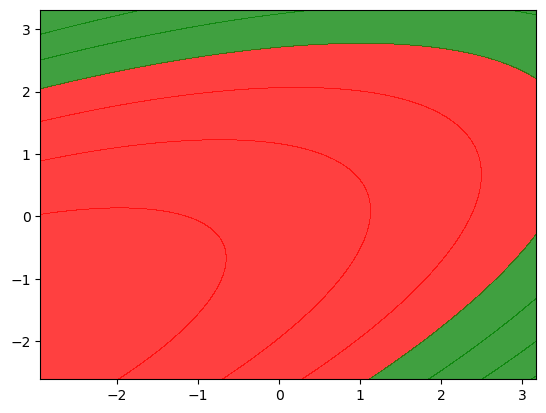

In [31]:
#plt.figure(figsize=(10, 6))
plt.contourf(X1, X2_grid, predictions_grid, alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2_grid.min(), X2_grid.max())
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_5220\3540521601.py:2: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


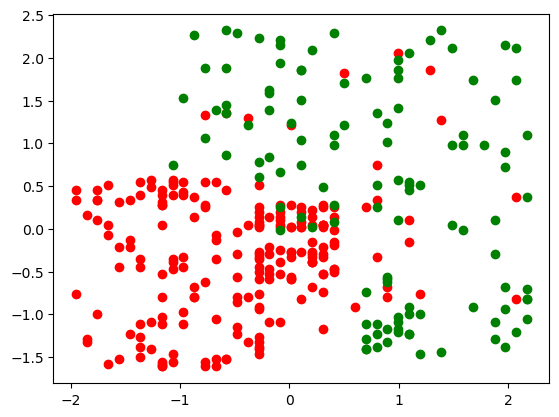

In [32]:
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = f'Class {j}')

C:\Users\PC\AppData\Local\Temp\ipykernel_5220\1679463597.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


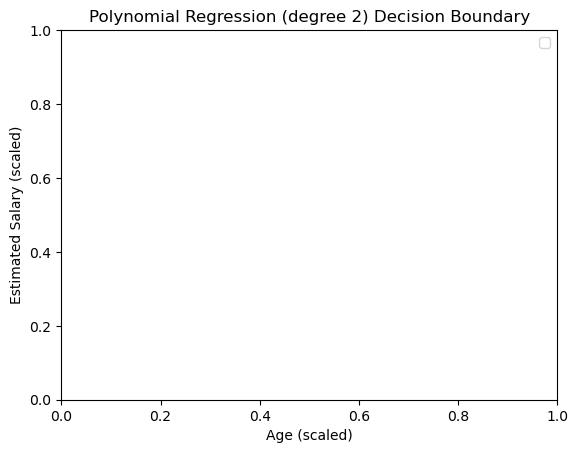

In [33]:
plt.title(f'Polynomial Regression (degree 2) Decision Boundary')
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.legend()
plt.show()